# Credit Default Case — Update 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

data_path = "../../data/loanskpi.csv"
df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Shape: 9578 rows x 17 columns


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,default,tot.payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


## 1. Correlations between variables

We look at pairwise linear relationships among the numeric loan variables,
then zoom in on two pairs of interest: interest rate vs. FICO score, and
revolving balance vs. revolving utilization.

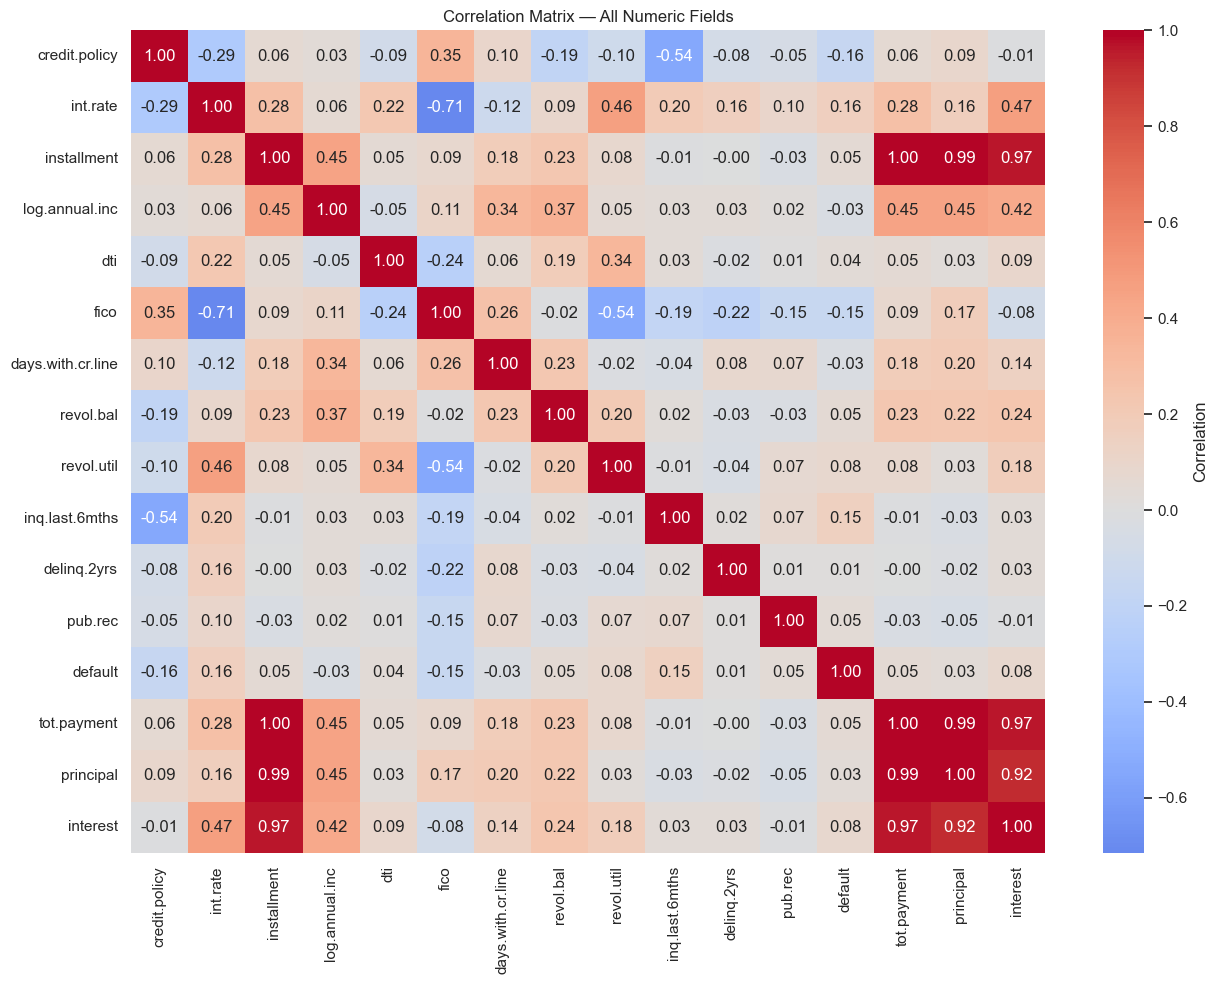

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — All Numeric Fields')
plt.tight_layout()
plt.show()

In [3]:
top_n = 15
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename('correlation')
        .reset_index()
        .rename(columns={'level_0': 'var_1', 'level_1': 'var_2'})
)
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.sort_values('abs_correlation', ascending=False).drop(columns='abs_correlation')

display(corr_pairs.head(top_n).reset_index(drop=True))

,var_1,var_2,correlation
0,installment,tot.payment,1.000000
1,tot.payment,principal,0.990172
2,installment,principal,0.990172
3,installment,interest,0.966023
4,tot.payment,interest,0.966023
5,principal,interest,0.920382
6,int.rate,fico,-0.714821
7,fico,revol.util,-0.541289
8,credit.policy,inq.last.6mths,-0.535511
9,int.rate,interest,0.471355


### 1.1 Interest rate vs. FICO score

Correlation (int.rate, fico): -0.715


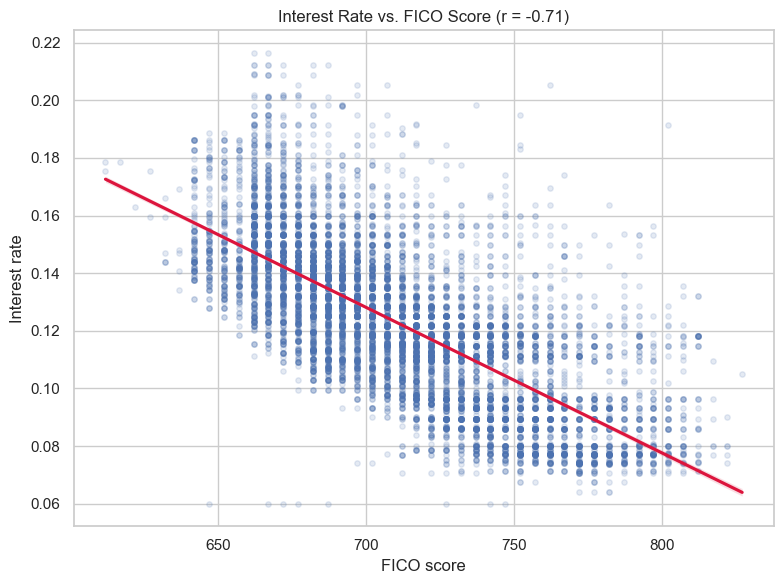

In [4]:
r_rate_fico = df['int.rate'].corr(df['fico'])
print(f"Correlation (int.rate, fico): {r_rate_fico:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='fico', y='int.rate', scatter_kws={'alpha': 0.15, 's': 15},
            line_kws={'color': 'crimson'})
plt.title(f'Interest Rate vs. FICO Score (r = {r_rate_fico:.2f})')
plt.xlabel('FICO score')
plt.ylabel('Interest rate')
plt.tight_layout()
plt.show()

### 1.2 Revolving balance vs. revolving utilization

Correlation (revol.bal, revol.util), full data: 0.204


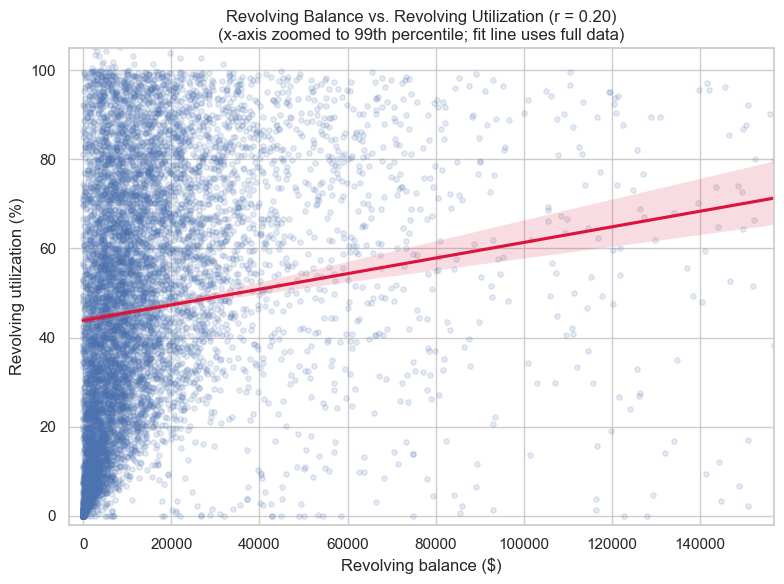

In [5]:
r_bal_util = df['revol.bal'].corr(df['revol.util'])
print(f"Correlation (revol.bal, revol.util), full data: {r_bal_util:.3f}")

x_cap = df['revol.bal'].quantile(0.99)
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='revol.bal', y='revol.util', scatter_kws={'alpha': 0.15, 's': 15},
            line_kws={'color': 'crimson'})
plt.xlim(-x_cap * 0.02, x_cap)
plt.ylim(-2, 105)
plt.title(f'Revolving Balance vs. Revolving Utilization (r = {r_bal_util:.2f})\n'
          f'(x-axis zoomed to 99th percentile; fit line uses full data)')
plt.xlabel('Revolving balance ($)')
plt.ylabel('Revolving utilization (%)')
plt.tight_layout()
plt.show()

## 2. Choosing the variable set for the logistic regression

We build the default model only from information Lending Club actually has
**at the time of the loan application** — anything computed after the loan
plays out cannot be used to screen new applications. We then use the
correlation analysis above to avoid feeding the model redundant,
near-duplicate signals.

**Step 1 — drop post-outcome variables.** `tot.payment`, `principal`, and
`interest` are only known once a loan has been repaid (or defaulted), so
they are unusable for screening a new application and are excluded outright
regardless of how predictive they look in-sample.

**Step 2 — drop `credit.policy`.** This flag records whether Lending Club's
*own* rule-based policy would have approved the loan. Using it to predict
default would mean re-deriving a variant of the existing policy rather than
building an independent screening signal, so we leave it out of the
predictive feature set (though it remains useful later as a benchmark to
compare our model against).

**Step 3 — resolve the most highly correlated pair.** From the heatmap and
ranked table in Section 1, one application-time pair stands out well above
the rest:

- **`int.rate` vs. `fico`** (r ≈ -0.71): Lending Club sets `int.rate`
  *using* FICO (and other risk factors) as part of its own pricing model.
  Including both would let the model partly re-derive `fico` from
  `int.rate` (or vice versa), inflating apparent significance without
  adding independent information. Because `int.rate` is Lending Club's own
  risk-pricing output — closer to a restatement of risk than a cause of
  it — we keep the more primitive, independently-observed `fico` and drop
  `int.rate`.

Other pairs (e.g. `revol.bal` vs. `revol.util` at r ≈ 0.20, or `fico` vs.
`revol.util` at r ≈ -0.54, confirmed in Section 2.1 below) are moderate at
most and each variable in the pair captures a genuinely distinct concept
(e.g. absolute balance vs. utilization rate, or credit score vs. revolving
behavior), so we retain both members of those pairs rather than treating
them as redundant.

In [6]:
# All fields known at application time (excludes post-outcome fields and
# Lending Club's own policy flag, both discussed above)
post_outcome_vars = ['tot.payment', 'principal', 'interest']
policy_var = ['credit.policy']
application_time_vars = [c for c in numeric_cols if c not in post_outcome_vars + policy_var + ['default']]
print("Application-time candidate variables:")
print(application_time_vars)

Application-time candidate variables:
['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']


In [7]:
# Drop int.rate: it is Lending Club's own risk-based pricing output and is
# highly correlated with fico (r ~ -0.71); keeping both would double-count
# the same underlying risk signal.
model_vars = [c for c in application_time_vars if c != 'int.rate']

print("Final variable set for the logistic regression model:")
for v in model_vars:
    print(f"  - {v}")

Final variable set for the logistic regression model:
  - installment
  - log.annual.inc
  - dti
  - fico
  - days.with.cr.line
  - revol.bal
  - revol.util
  - inq.last.6mths
  - delinq.2yrs
  - pub.rec


### 2.1 Confirming the final set is not multicollinear

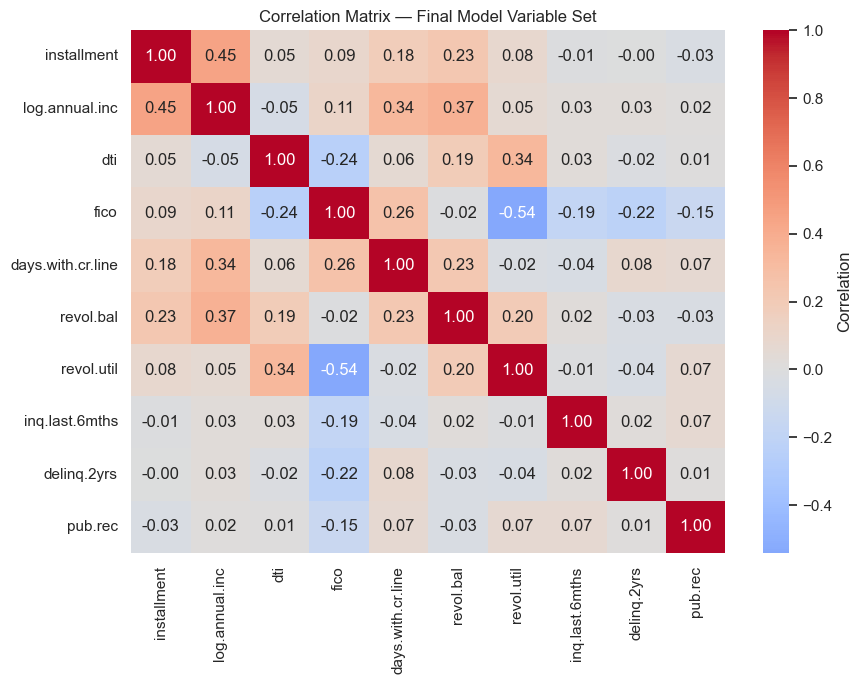

Largest remaining |correlation| among selected variables: 0.541


In [8]:
model_corr = df[model_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(model_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Final Model Variable Set')
plt.tight_layout()
plt.show()

max_offdiag = model_corr.where(np.triu(np.ones(model_corr.shape), k=1).astype(bool)).abs().max().max()
print(f"Largest remaining |correlation| among selected variables: {max_offdiag:.3f}")

The strongest remaining pair is `fico` vs. `revol.util` (r ≈ -0.54) —
notable, but well short of the ~0.7 level that drove us to drop `int.rate`,
and conceptually distinct (a lender-assigned credit score vs. the
borrower's own revolving-credit behavior). We retain both.

**Final model variable set:** `installment`, `log.annual.inc`, `dti`,
`fico`, `days.with.cr.line`, `revol.bal`, `revol.util`, `inq.last.6mths`,
`delinq.2yrs`, `pub.rec` — ten application-time variables covering loan
size, income, indebtedness, credit quality, credit history length,
revolving credit exposure and utilization, and recent credit-seeking /
delinquency behavior, with no pair strongly enough correlated to be
considered redundant.